[[ 0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.07851963]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.23507479]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.39018064]
 [ 0

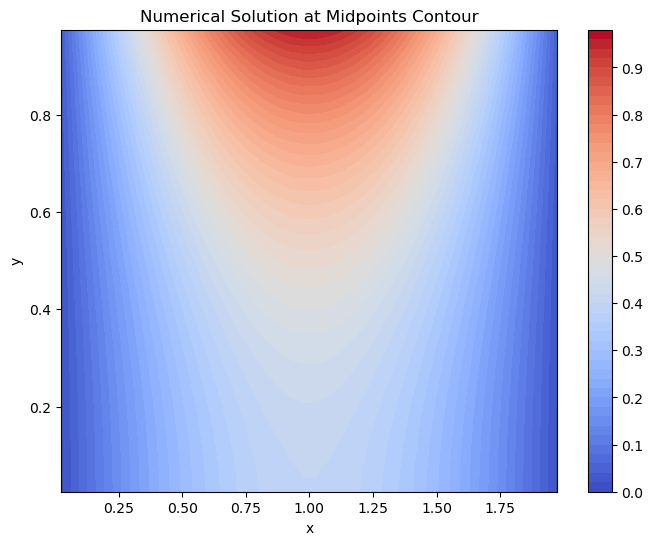

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Lx, Ly = 2.0, 1.0
nx, ny = 40,20
dx, dy = Lx / nx, Ly / ny
tolerance = 1e-12

# Initialize temperature array including ghost cells
T = np.zeros((nx + 2, ny + 2))

# Function to set boundary conditions
def set_boundary_conditions(T, nx, ny, dx, dy):
    for i in range(1, nx + 1):  # Top boundary (y = 1)
        x = (i - 0.5) * dx
        T[i, ny + 1] = 2 * np.sin(np.pi * x / 2) - T[i, ny]

    for i in range(1, nx + 1):  # Bottom boundary (y = 0)
        T[i, 0] = T[i, 1]

    for j in range(1, ny + 1):  # Left boundary (x = 0)
        T[0, j] = -T[1, j]

    for j in range(1, ny + 1):  # Right boundary (x = Lx)
        T[nx + 1, j] = -T[nx, j]

    return T
print(f"The boundary conditions are initialized with arrays \n {set_boundary_conditions(T, nx, ny, dx, dy)}")

# Gauss-Seidel iteration function
def gauss_seidel_iteration(T, nx, ny):
    for i in range(1, nx + 1):
        for j in range(1, ny + 1):
            T[i, j] = 0.25 * (T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1])
    return T

# L2 norm calculation
def L2_normalization(T, old_T, nx, ny):
    diff = T[1:nx+1, 1:ny+1] - old_T[1:nx+1, 1:ny+1]
    return np.sqrt(np.sum(diff**2)/(nx*ny))


# Apply boundary conditions
T = set_boundary_conditions(T, nx, ny, dx, dy)

# Iterative solution with Gauss-Seidel
iteration = 0
L2_norm = 1e10
while L2_norm > tolerance:
    old_T = T.copy()
    T = gauss_seidel_iteration(T, nx, ny)
    T = set_boundary_conditions(T, nx, ny, dx, dy)  # Reapply boundary conditions
    L2_norm = L2_normalization(T, old_T, nx, ny)
    iteration += 1
print(f"Solution converged after {iteration} number of iterations")
print(f"The Value of the L2 norm is {L2_norm}")


# Plotting function
def plot_solution_midpoints(T, nx, ny, dx, dy):
    x = np.linspace(dx / 2, Lx - dx / 2, nx)  # Midpoints along x
    y = np.linspace(dy / 2, Ly - dy / 2, ny)  # Midpoints along y
    X, Y = np.meshgrid(x, y)

    # Extract the interior points (excluding ghost cells)
    T_midpoints = T[1:nx + 1, 1:ny + 1]

    plt.figure(figsize=(8, 6))
    contour = plt.contourf(X, Y, T_midpoints.T, levels=50, cmap='coolwarm') 
    plt.colorbar(contour)  # Add color bar
    plt.title("Numerical Solution at Midpoints Contour")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

plot_solution_midpoints(T, nx, ny, dx, dy)

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.01565855 0.01575519 0.01594906 0.01624137 0.01663391
  0.01712912 0.01773004 0.01844038 0.01926453 0.02020758 0.02127533
  0.0224744  0.02381217 0.0252969  0.02693775 0.02874486 0.03072936
  0.03290353 0.03528076 0.03787573 0.        ]
 [0.         0.0468791  0.04716843 0.04774886 0.04862398 0.04979919
  0.05128175 0.0530808  0.05520745 0.05767482 0.06049814 0.06369483
  0.06728463 0.07128969 0.07573473 0.08064717 0.08605735 0.09199864
  0.09850771 0.10562475 0.11339367 0.        ]
 [0.         0.07781063 0.07829086 0.07925426 0.0807068  0.08265744
  0.08511821 0.0881043  0.09163414 0.09572952 0.10041571 0.10572163
  0.11168004 0.11832769 0.12570563 0.13385938 0.14283927 0.15270071
  0.16350457 0.17531753 0.18821249 0.        ]
 [0.         0.10826

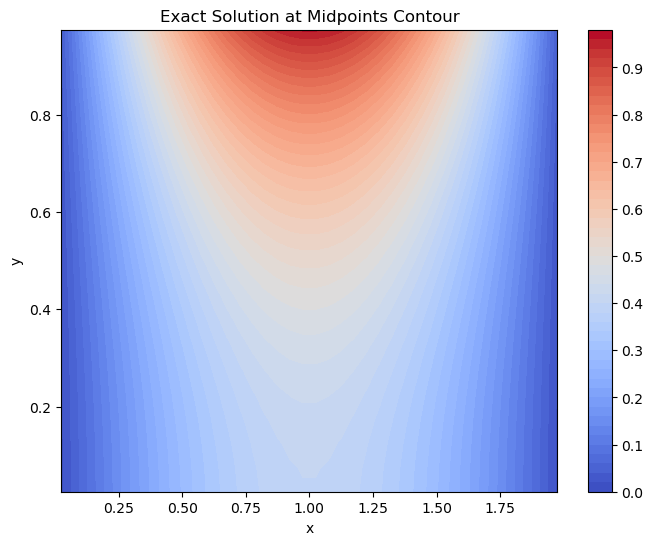

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the grid
Lx, Ly = 2.0, 1.0
nx, ny = 40,20
dx, dy = Lx / nx, Ly / ny

# Function to compute the exact solution at cell centers
def exact_solution(nx, ny, dx, dy):
    T_exact = np.zeros((nx + 2, ny + 2))
    for i in range(1, nx + 1):
        for j in range(1, ny + 1):
            x = (i - 0.5) * dx
            y = (j - 0.5) * dy
            T_exact[i, j] = (np.sin(np.pi * x / 2) *
                             np.cosh(np.pi * y / 2) /
                             np.cosh(np.pi / 2))
    return T_exact

# Compute the exact solution
T_exact = exact_solution(nx, ny, dx, dy)
print(T_exact)

def plot_exact_solution_midpoints(T, nx, ny, dx, dy):
    x = np.linspace(dx / 2, Lx - dx / 2, nx)  # Midpoints along x
    y = np.linspace(dy / 2, Ly - dy / 2, ny)  # Midpoints along y
    X, Y = np.meshgrid(x, y)

    # Extract the interior points (excluding ghost cells)
    T_midpoints = T[1:nx + 1, 1:ny + 1]

    plt.figure(figsize=(8, 6))
    contour = plt.contourf(X, Y, T_midpoints.T, levels=50, cmap='coolwarm') 
    plt.colorbar(contour)  # Add color bar
    plt.title("Exact Solution at Midpoints Contour")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

plot_exact_solution_midpoints(T_exact, nx, ny, dx, dy)

## L2 Norm Error

In [10]:
def L2_Norm_Error(T,T_exact):
    diff = T[1:nx+1, 1:ny+1] - T_exact[1:nx+1, 1:ny+1]
    # Calculate the L2 norm error
    L2_norm_error = np.sqrt(np.sum(diff**2) / (nx * ny))
    return L2_norm_error
L2_Norm_Error(T,T_exact)

0.00022309654926785884

In [8]:
print(T) #T represents tbe numerical solution values 
print(T_exact)

[[ 0.         -0.01565806 -0.0157546  -0.01594827 -0.01624027 -0.01663239
  -0.01712706 -0.01772732 -0.01843687 -0.0192601  -0.02020207 -0.02126859
  -0.02246624 -0.0238024  -0.02528531 -0.02692412 -0.02872892 -0.03071084
  -0.03288211 -0.0352561  -0.03784746  0.        ]
 [ 0.01565806  0.01565806  0.0157546   0.01594827  0.01624027  0.01663239
   0.01712706  0.01772732  0.01843687  0.0192601   0.02020207  0.02126859
   0.02246624  0.0238024   0.02528531  0.02692412  0.02872892  0.03071084
   0.03288211  0.0352561   0.03784746  0.04067217]
 [ 0.04687765  0.04687765  0.04716667  0.04774648  0.04862067  0.04979462
   0.05127557  0.05307265  0.05519695  0.05766155  0.06048165  0.06367464
   0.06726021  0.07126045  0.07570005  0.08060636  0.08600963  0.09194318
   0.09844359  0.10555094  0.11330905  0.12176574]
 [ 0.07780823  0.07780823  0.07828794  0.07925033  0.08070132  0.08264986
   0.08510796  0.08809078  0.09161671  0.09570749  0.10038834  0.10568811
   0.11163949  0.11827916  0.1256